This notebook lets the user find the air exchanges per hour neccecary to limit the probability of infection (as calculated by CAiMIRA) below a predefined threashold.

In [1]:
from caimira.ventilation.ventilation import *
from caimira.ventilation.scenarios import *
from caimira.ventilation.get_models import *

In [2]:
scenario = scenarios.shared_office() # Scenarios tested: shared_office, classroom, patient_ward, ICU. No short range interactions.

lim_probability_infection_list = [0.1, 0.075, 0.05]
lim_probability_infection = lim_probability_infection_list[1]

0 ACH   =>   P(I) = 12.72%, Dose = 7.82


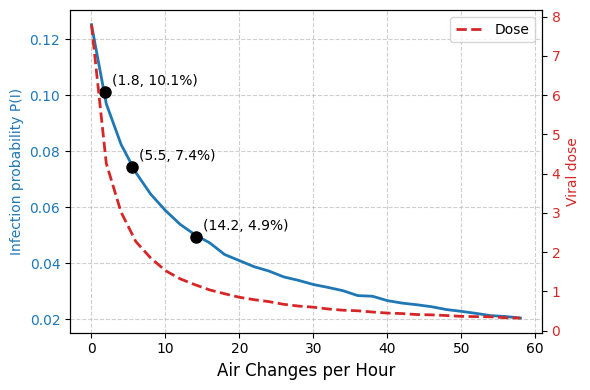

In [3]:
plot_probabilities(scenario, lim_probability_infection_list)

In [4]:
air_exch, probability = find_constant_air_exch(scenario, lim_probability_infection)

NOTE:

Variability between model runs may cause the probability of infection to be slightly higher than lim_probability_infection.

Inhaled dose:  2.4525 [0.0 - 11.0]
Probability of infection:  0.0748 [0.0 - 1.0]
Air changes per hour: Mean: 5.368820295433462, All values: [5.37]
Clean air delivery (L/s/person): Mean: inf, All values: [np.float64(18.641737136921744), inf, np.float64(18.641737136921744)]
Max CO2: 756.96


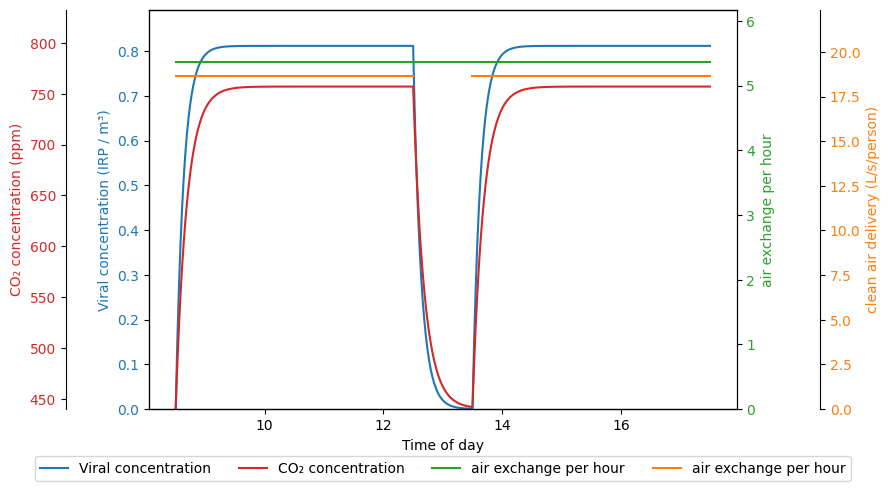

In [5]:
plot_model_concentration_results(scenario, air_exch, deterministic_CO2=True, plot_clean_air_delivery=True)

In [6]:
air_exch_l, vent_transition_t = find_next_air_exch_by_co2(
    scenario,
    air_exch_list=[0.25],                                     # No ventilation
    vent_transition_times=None,                               # 
    max_CO2=750,                                              # Define a reasonable limit from the above plot (TODO: scale limit by number of occupants to make sense of scenarios where people come and go)
    min_CO2_fraction=0.9,                                     # Determines the lower limit for the CO2 concentration. Ventilation is decreased when reaching this point
    target_CO2_fraction=0.95,
    max_ventilation_changes=5
)

In [7]:
for a, v in zip(air_exch_l, vent_transition_t):
    print(v, a)

8.5 0.25
8.689000000000007 6.246807151167052


Inhaled dose:  2.2373 [0.0 - 10.0]
Probability of infection:  0.0714 [0.0 - 1.0]
Air changes per hour: Mean: 3.248403575583526, All values: [0.25, np.float64(6.25)]
Clean air delivery (L/s/person): Mean: inf, All values: [np.float64(0.8680555555555556), np.float64(21.690302608218932), inf, np.float64(21.690302608218932)]
Max CO2: 754.15


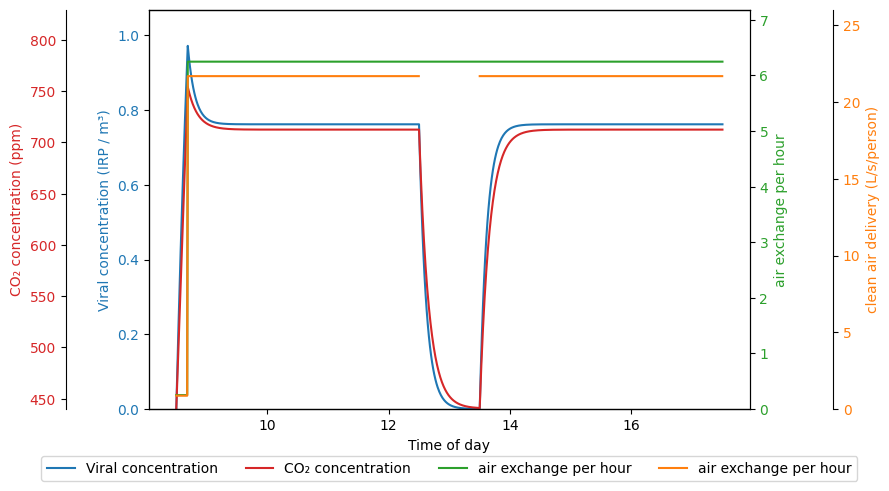

In [8]:
plot_model_concentration_results(scenario, air_exch_l, vent_transition_t, deterministic_CO2=True)

NOTE: 

FEEDBACK CO2 THRESHOLD (propose a starting value from the profile, calculate P(I) and check if result is within limit, else set a lower value and reiterate)

When the number of ventilation changes is defined as less than the model's number of state changes, the CO2 concentration may increase beyond the max CO2 limit (and similarly below the min CO2 limit). 

This also means that the probability of infection is not neccecarily <= lim_probability_infection. 